In [7]:
#Load the DMI dataset and inspect basic structure
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
# Load dataset
weather = pd.read_csv("dmi_station06072_2022_2024_temp_wind_solar_clean.csv")

# Basic inspection
print("Shape:", weather.shape)
print("\nColumns:")
print(weather.columns)

print("\nFirst 5 rows:")
display(weather.head())

print("\nData types:")
print(weather.dtypes)

Shape: (153437, 5)

Columns:
Index(['datetime_utc', 'datetime_dk', 'temperature', 'wind_speed',
       'solar_radiation'],
      dtype='str')

First 5 rows:


,datetime_utc,datetime_dk,temperature,wind_speed,solar_radiation
0,2022-01-01T00:00:00Z,2022-01-01T00:00:00Z,6.8,3.7,1.0
1,2022-01-01T00:10:00Z,2022-01-01T00:10:00Z,6.7,3.5,1.0
2,2022-01-01T00:20:00Z,2022-01-01T00:20:00Z,6.6,3.1,1.0
3,2022-01-01T00:30:00Z,2022-01-01T00:30:00Z,6.7,3.1,1.0
4,2022-01-01T00:40:00Z,2022-01-01T00:40:00Z,6.5,3.8,1.0



Data types:
datetime_utc           str
datetime_dk            str
temperature        float64
wind_speed         float64
solar_radiation    float64
dtype: object


In [9]:
#Convert timestamps to datetime
# Convert timestamp columns to datetime format
weather['datetime_utc'] = pd.to_datetime(weather['datetime_utc'])
weather = weather.drop(columns=['datetime_dk'])

# Check result
print(weather.dtypes)

# Show first rows again
weather.head()

datetime_utc       datetime64[us, UTC]
temperature                    float64
wind_speed                     float64
solar_radiation                float64
dtype: object


,datetime_utc,temperature,wind_speed,solar_radiation
0,2022-01-01 00:00:00+00:00,6.8,3.7,1.0
1,2022-01-01 00:10:00+00:00,6.7,3.5,1.0
2,2022-01-01 00:20:00+00:00,6.6,3.1,1.0
3,2022-01-01 00:30:00+00:00,6.7,3.1,1.0
4,2022-01-01 00:40:00+00:00,6.5,3.8,1.0


The original dataset contained both `datetime_utc` and `datetime_dk` columns.  
but the `datetime_utc` column was used as the primary timestamp during preprocessing. All data processing and aggregation were performed in UTC to avoid ambiguities related to daylight saving time transitions. Danish local time (CET/CEST) will be applied later when merging the datasets.

In [10]:
# Sort dataset by time
weather = weather.sort_values('datetime_utc')

# Check duplicate timestamps
duplicate_count = weather["datetime_utc"].duplicated().sum()
print("Duplicate timestamps:", duplicate_count)

# Reset index
weather = weather.reset_index(drop=True)

# Check first rows again
weather.head()

Duplicate timestamps: 0


,datetime_utc,temperature,wind_speed,solar_radiation
0,2022-01-01 00:00:00+00:00,6.8,3.7,1.0
1,2022-01-01 00:10:00+00:00,6.7,3.5,1.0
2,2022-01-01 00:20:00+00:00,6.6,3.1,1.0
3,2022-01-01 00:30:00+00:00,6.7,3.1,1.0
4,2022-01-01 00:40:00+00:00,6.5,3.8,1.0


Because time-series modelling requires timestamps in datetime format to allow temporal aggregation, lag feature creation, and proper alignment when merging datasets.

In [11]:
#check irregular time gaps
# Calculate time difference between consecutive rows
weather['time_diff'] = weather['datetime_utc'].diff()

# Convert difference to minutes
weather['time_diff_min'] = weather['time_diff'].dt.total_seconds() / 60

# Count different gap sizes
gap_counts = weather['time_diff_min'].value_counts().sort_index()

print(gap_counts)

time_diff_min
4.0             1
6.0             1
10.0       153366
20.0           44
30.0            5
50.0            4
60.0            1
70.0            3
110.0           1
120.0           1
130.0           2
350.0           1
520.0           1
580.0           1
2400.0          1
5660.0          1
12200.0         1
20860.0         1
Name: count, dtype: int64


In [12]:
#Find Missing Timestamps
# Create full expected timeline (10-minute frequency)
full_range = pd.date_range(
    start=weather['datetime_utc'].min(),
    end=weather['datetime_utc'].max(),
    freq='10min'
)

# Find missing timestamps
missing_times = full_range.difference(weather['datetime_utc'])

print("Number of missing timestamps:", len(missing_times))

# Show first few
missing_times[:10]

Number of missing timestamps: 4388


DatetimeIndex(['2022-01-02 05:20:00+00:00', '2022-01-02 05:30:00+00:00',
               '2022-01-04 18:10:00+00:00', '2022-01-25 08:30:00+00:00',
               '2022-01-25 15:20:00+00:00', '2022-02-21 14:20:00+00:00',
               '2022-02-21 14:30:00+00:00', '2022-02-21 14:40:00+00:00',
               '2022-02-21 14:50:00+00:00', '2022-03-01 00:00:00+00:00'],
              dtype='datetime64[us, UTC]', freq=None)

In [13]:
#Insert Missing Timestamps
# Set datetime as index
weather = weather.set_index('datetime_utc')

# Create full timeline
full_range = pd.date_range(
    start=weather.index.min(),
    end=weather.index.max(),
    freq='10min'
)

# Reindex dataset to include missing timestamps
weather = weather.reindex(full_range)

# Rename index
weather.index.name = "datetime_utc"

# Check result
weather.head()

,temperature,wind_speed,solar_radiation,time_diff,time_diff_min
datetime_utc,,,,,
2022-01-01 00:00:00+00:00,6.8,3.7,1.0,NaT,NaN
2022-01-01 00:10:00+00:00,6.7,3.5,1.0,0 days 00:10:00,10.0
2022-01-01 00:20:00+00:00,6.6,3.1,1.0,0 days 00:10:00,10.0
2022-01-01 00:30:00+00:00,6.7,3.1,1.0,0 days 00:10:00,10.0
2022-01-01 00:40:00+00:00,6.5,3.8,1.0,0 days 00:10:00,10.0


In [14]:
#Compare missing-value methods
# Check missing values after reindexing
print("Missing values after reindexing:")
print(weather[['temperature', 'wind_speed', 'solar_radiation']].isna().sum())

Missing values after reindexing:
temperature        8330
wind_speed         4409
solar_radiation    4424
dtype: int64


In [15]:
#Identify a small gap period(not needed)
# Find rows where temperature was missing before imputation
missing_temp = weather['temperature'].isna()

# Get first missing timestamp
first_missing_time = weather[missing_temp].index[0]

print("First missing timestamp:", first_missing_time)

First missing timestamp: 2022-01-02 05:20:00+00:00


In [16]:
#Quick EDA
# Summary statistics
weather[['temperature','wind_speed','solar_radiation']].describe()

,temperature,wind_speed,solar_radiation
count,149494.000000,153415.000000,153400.000000
mean,9.437800,3.197725,117.987203
std,6.533619,2.013133,197.590150
min,-14.200000,0.000000,0.000000
25%,4.600000,1.700000,0.000000
50%,9.500000,2.900000,5.000000
75%,14.300000,4.400000,158.000000
max,29.900000,17.500000,1317.000000


Exploratory data analysis (EDA) was conducted to verify the quality and distribution of the meteorological variables before aggregation. The analysis confirmed that the values were within realistic physical ranges.

In [17]:
#Interpolation only fills values between two known observations.
#We combine interpolation + forward/backward fill as all the observation is not equal ,find from above output.
weather[['temperature','wind_speed','solar_radiation']] = (
    weather[['temperature','wind_speed','solar_radiation']]
    .interpolate(method='time')
    .ffill()
    .bfill()
)

In [18]:
weather[['temperature','wind_speed','solar_radiation']].isna().sum()

temperature        0
wind_speed         0
solar_radiation    0
dtype: int64

In [19]:
#Quick EDA
# Summary statistics
weather[['temperature','wind_speed','solar_radiation']].describe()

,temperature,wind_speed,solar_radiation
count,157824.000000,157824.000000,157824.000000
mean,9.164613,3.225533,117.145859
std,6.485057,2.012446,195.811022
min,-14.200000,0.000000,0.000000
25%,4.300252,1.700000,0.000000
50%,8.900000,2.912850,7.000000
75%,14.000000,4.400000,156.000000
max,29.900000,17.500000,1317.000000


Missing values were first filled using time-based interpolation because weather variables usually evolve smoothly over time. Any remaining missing values at the start or end of the series were filled using forward fill and backward fill so that the dataset became complete.


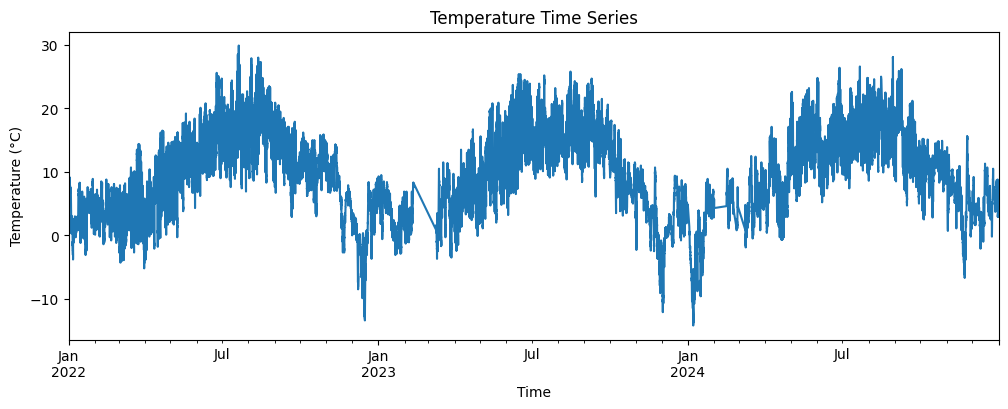

In [20]:
#Time Series Plot
plt.figure(figsize=(12,4))
weather['temperature'].plot()
plt.title("Temperature Time Series")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.show()

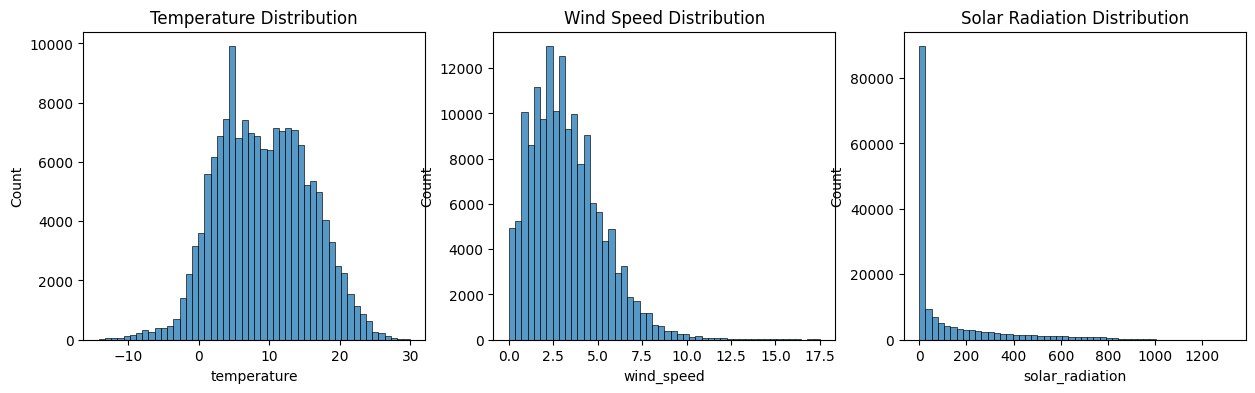

In [21]:
#Distribution Plots
import seaborn as sns

fig, ax = plt.subplots(1,3, figsize=(15,4))

sns.histplot(weather['temperature'], bins=50, ax=ax[0])
ax[0].set_title("Temperature Distribution")

sns.histplot(weather['wind_speed'], bins=50, ax=ax[1])
ax[1].set_title("Wind Speed Distribution")

sns.histplot(weather['solar_radiation'], bins=50, ax=ax[2])
ax[2].set_title("Solar Radiation Distribution")

plt.show()

Exploratory data analysis confirmed that the meteorological variables fall within realistic physical ranges. The temperature series exhibits clear seasonal variation, with higher values in summer and lower values in winter. Wind speed follows a right-skewed distribution typical of atmospheric wind patterns, while solar radiation shows a large concentration of values near zero corresponding to nighttime periods. These observations indicate that the dataset is consistent with expected meteorological behaviour.

In [22]:
#Aggregate Weather Data to Hourly
# Aggregate 10-minute data to hourly averages
weather_hourly = weather[['temperature','wind_speed','solar_radiation']].resample('h').mean()

weather_hourly.head()

,temperature,wind_speed,solar_radiation
datetime_utc,,,
2022-01-01 00:00:00+00:00,6.616667,3.566667,1.0
2022-01-01 01:00:00+00:00,6.266667,3.200000,1.0
2022-01-01 02:00:00+00:00,6.150000,2.750000,1.0
2022-01-01 03:00:00+00:00,6.016667,2.633333,1.0
2022-01-01 04:00:00+00:00,6.150000,2.050000,1.0


In [23]:
print(weather_hourly.shape)
weather_hourly.head()
weather_hourly.tail()

(26304, 3)


,temperature,wind_speed,solar_radiation
datetime_utc,,,
2024-12-31 19:00:00+00:00,7.616667,6.666667,0.0
2024-12-31 20:00:00+00:00,7.933333,7.033333,0.0
2024-12-31 21:00:00+00:00,8.016667,6.783333,0.0
2024-12-31 22:00:00+00:00,8.066667,6.375000,0.0
2024-12-31 23:00:00+00:00,8.350000,6.583333,0.0


All preprocessing and aggregation were performed in UTC to avoid ambiguities introduced by daylight saving time. After merging the datasets, timestamps were converted to Danish local time (CET/CEST) for interpretation.

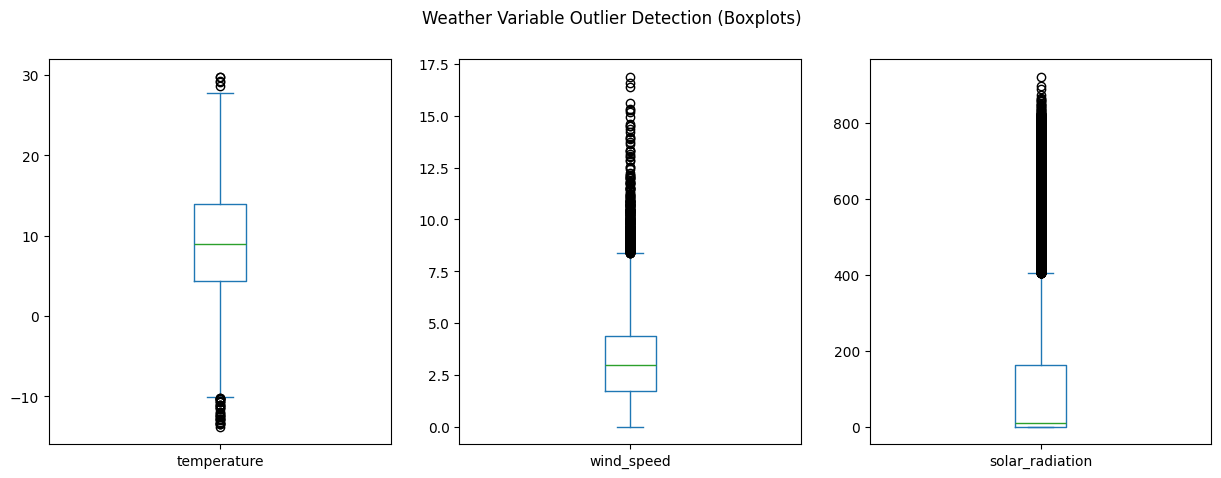

In [24]:
#outlier_check
import matplotlib.pyplot as plt

weather_hourly[['temperature','wind_speed','solar_radiation']].plot(
    kind='box',
    subplots=True,
    layout=(1,3),
    figsize=(15,5)
)

plt.suptitle("Weather Variable Outlier Detection (Boxplots)")
plt.show()

In [25]:
#iqr_for_outlier
def detect_outliers_iqr(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    
    print(f"{column} outliers:", len(outliers))
    
    return outliers

detect_outliers_iqr(weather_hourly,'temperature')
detect_outliers_iqr(weather_hourly,'wind_speed')
detect_outliers_iqr(weather_hourly,'solar_radiation')

temperature outliers: 38
wind_speed outliers: 404
solar_radiation outliers: 2882


,temperature,wind_speed,solar_radiation
datetime_utc,,,
2022-02-26 11:00:00+00:00,5.600000,1.483333,415.333333
2022-02-27 11:00:00+00:00,4.116667,4.433333,420.500000
2022-02-27 12:00:00+00:00,4.583333,3.366667,411.500000
2022-02-28 11:00:00+00:00,5.733333,5.300000,422.000000
2022-02-28 12:00:00+00:00,6.483333,6.666667,414.000000
...,...,...,...
2024-10-05 11:00:00+00:00,13.300000,1.533333,481.166667
2024-10-06 09:00:00+00:00,11.216667,2.800000,411.666667
2024-10-06 12:00:00+00:00,13.200000,3.816667,455.166667


### Outlier Analysis

Potential outliers in the meteorological variables were examined using boxplots and the interquartile range (IQR) method.

The analysis detected:
- 38 temperature outliers
- 404 wind speed outliers
- 2882 solar radiation outliers

Inspection of the boxplots and the physical ranges of the variables shows that these extreme values correspond to realistic meteorological conditions, such as very cold winter temperatures, strong wind events, and high solar radiation during sunny summer days.

Since these values represent natural environmental variability rather than measurement errors, no outlier removal was applied.

In [ ]:
#save the cleaned dataset:
weather_hourly.to_csv("weather_dk1_hourly_2022_2024.csv")

## Weather Data Processing (DMI Station 06072)

This section describes the preprocessing steps applied to the meteorological dataset obtained from the Danish Meteorological Institute (DMI).  
The dataset contains 10-minute observations of temperature, wind speed, and solar radiation for the Edema weather station located in the DK1 bidding zone.

### 1. Timestamp Handling

All timestamps were converted to `datetime` format to ensure compatibility with time-series analysis tools.  
The data were processed in **Coordinated Universal Time (UTC)** to avoid ambiguities caused by daylight saving time transitions.

### 2. Detection of Missing Timestamps

The dataset was expected to contain observations every 10 minutes.  
To verify this, a complete timeline with a 10-minute frequency was generated and compared with the original timestamps.  
Missing timestamps were identified and inserted using reindexing, ensuring a continuous time index.

### 3. Handling Missing Values

Missing observations in the meteorological variables were handled using a three-step approach:

1. **Time-based interpolation** was applied to estimate values between known observations, preserving the smooth temporal behaviour of weather variables.
2. **Forward filling (ffill)** was used to propagate the last valid observation forward when interpolation could not estimate edge values.
3. **Backward filling (bfill)** was applied to fill remaining missing values at the beginning of the dataset.
This approach ensured a complete dataset while maintaining realistic meteorological patterns.



This approach ensured a complete dataset while maintaining realistic meteorological patterns.

### 4. Exploratory Data Analysis (EDA)

Exploratory analysis was performed to validate the dataset:

- The temperature time series exhibits clear seasonal patterns consistent with Danish climate conditions.
- Wind speed shows a right-skewed distribution typical of atmospheric wind behaviour.
- Solar radiation contains many zero values corresponding to nighttime periods.

The observed ranges of the variables are physically realistic and consistent with expected meteorological conditions.

### 5. Temporal Aggregation

The original weather observations were recorded at **10-minute intervals**.  
To align with the resolution of the electricity consumption and CO₂ intensity datasets, the meteorological variables were aggregated to **hourly values** using the mean of the six observations within each hour.

### 6. Final Weather Dataset

The final processed dataset contains hourly observations with the following variables:

- Temperature (°C)
- Wind speed (m/s)
- Solar radiation (W/m²)

The resulting dataset spans the period **2022–2024** and contains **26,304 hourly observations**, corresponding to three years of data including the leap year 2024.


DMI Weather Dataset
      ↓
Timestamp conversion
      ↓
Missing timestamp detection
      ↓
Reindex timeline
      ↓
Interpolation + ffill + bfill
      ↓
EDA validation
      ↓
10-minute → hourly aggregation
      ↓
UTC processing
      ↓
Final hourly weather dataset